In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import warnings

warnings.filterwarnings('ignore')
%matplotlib inline

In [2]:
from sklearn.preprocessing import LabelEncoder

def create_df(dic, feature_list):
    out = pd.DataFrame(dic)
    out = pd.concat([out, pd.get_dummies(out[feature_list])], axis=1)
    out.drop(feature_list, axis=1, inplace=True)
    return out

def intersect_features(train, test):
    common_feat = list(set(train.keys()) & set(test.keys()))
    return train[common_feat], test[common_feat]

features = ['Looks', 'Alcoholic_beverage', 'Eloquence', 'Money_spent']

### Training data

In [3]:
df_train = {}
df_train['Looks'] = ['handsome', 'handsome', 'handsome', 'repulsive', 'repulsive', 'repulsive', 'handsome']
df_train['Alcoholic_beverage'] = ['yes', 'yes', 'no', 'no', 'yes', 'yes', 'yes']
df_train['Eloquence'] = ['high', 'low', 'average', 'average', 'low', 'high', 'average']
df_train['Money_spent'] = ['lots', 'little', 'lots', 'little', 'lots', 'lots', 'lots']
df_train['Will_go'] = LabelEncoder().fit_transform(['+', '-', '+', '-', '-', '+', '+'])

df_train = create_df(df_train, features)
print("Training data:")
df_train

Training data:


,Will_go,Looks_handsome,Looks_repulsive,Alcoholic_beverage_no,Alcoholic_beverage_yes,Eloquence_average,Eloquence_high,Eloquence_low,Money_spent_little,Money_spent_lots
0,0,True,False,False,True,False,True,False,False,True
1,1,True,False,False,True,False,False,True,True,False
2,0,True,False,True,False,True,False,False,False,True
3,1,False,True,True,False,True,False,False,True,False
4,1,False,True,False,True,False,False,True,False,True
5,0,False,True,False,True,False,True,False,False,True
6,0,True,False,False,True,True,False,False,False,True


### Test data

In [4]:
df_test = {}
df_test['Looks'] = ['handsome', 'handsome', 'repulsive']
df_test['Alcoholic_beverage'] = ['no', 'yes', 'yes']
df_test['Eloquence'] = ['average', 'high', 'average']
df_test['Money_spent'] = ['lots', 'little', 'lots']

df_test = create_df(df_test, features)
print("Test data:")
df_test

Test data:


,Looks_handsome,Looks_repulsive,Alcoholic_beverage_no,Alcoholic_beverage_yes,Eloquence_average,Eloquence_high,Money_spent_little,Money_spent_lots
0,True,False,True,False,True,False,False,True
1,True,False,False,True,False,True,True,False
2,False,True,False,True,True,False,False,True


In [5]:
y = df_train['Will_go']
df_train, df_test = intersect_features(train=df_train, test=df_test)

print("\nAfter feature alignment:")
print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")
print(f"\nWill_go distribution: {pd.Series(y).value_counts().to_dict()}")
df_train.head()


After feature alignment:
Train shape: (7, 8)
Test shape: (3, 8)

Will_go distribution: {0: 4, 1: 3}


,Eloquence_average,Looks_handsome,Alcoholic_beverage_no,Money_spent_lots,Eloquence_high,Looks_repulsive,Alcoholic_beverage_yes,Money_spent_little
0,False,True,False,True,True,False,True,False
1,False,True,False,False,False,False,True,True
2,True,True,True,True,False,False,False,False
3,True,False,True,False,False,True,False,True
4,False,False,False,True,False,True,True,False


---
## Question 3.1: What is the entropy S0 of the initial system?

In [6]:
from math import log

print("Target distribution:")
print(pd.Series(y).value_counts())
print()

# Total samples
total = len(y)
print(f"Total samples: {total}")
print()

# Count 0s and 1s
count_0 = (y == 0).sum()  # not go
count_1 = (y == 1).sum()  # go

print(f"Will NOT go (0): {count_0}")
print(f"Will go (1): {count_1}")
print()

# Calculate probabilities
# Original: 3 '+' and 4 '-' 
# After encoding: 3 ones (1) and 4 zeros (0)
p_0 = count_0 / total
p_1 = count_1 / total

print(f"P(0) = {count_0}/{total} = {p_0:.3f}")
print(f"P(1) = {count_1}/{total} = {p_1:.3f}")
print()

# Calculate entropy: S = -sum(p * log2(p))
# S0 = -(4/7)*log2(4/7) - (3/7)*log2(3/7)
entropy_s0 = -(p_0 * log(p_0, 2) + p_1 * log(p_1, 2))

print(f"Entropy S0 = -({count_0}/{total})*log2({count_0}/{total}) - ({count_1}/{total})*log2({count_1}/{total})")
print(f"Entropy S0 = {entropy_s0:.3f}")

Target distribution:
Will_go
0    4
1    3
Name: count, dtype: int64

Total samples: 7

Will NOT go (0): 4
Will go (1): 3

P(0) = 4/7 = 0.571
P(1) = 3/7 = 0.429

Entropy S0 = -(4/7)*log2(4/7) - (3/7)*log2(3/7)
Entropy S0 = 0.985


---
## Question 3.2: Split by 'Looks_handsome' feature - entropy S1, S2, and information gain

In [7]:
from math import log

print("Splitting by 'Looks_handsome' feature:")
print(f"Available features: {df_train.columns.tolist()}")
print()

# Group 1: Looks_handsome = True
group1_mask = df_train['Looks_handsome'] == True
y_group1 = y[group1_mask]

print(f"Group 1 (Looks_handsome = True):")
print(f"  Size: {len(y_group1)}")
print(f"  Distribution: {pd.Series(y_group1).value_counts().to_dict()}")
print(f"  0 (won't go): {(y_group1 == 0).sum()}, 1 (will go): {(y_group1 == 1).sum()}")

# S1 = -(3/4)*log2(3/4) - (1/4)*log2(1/4)
# In encoded data: 3 zeros (won't go) and 1 one (will go)
p1_0 = (y_group1 == 0).sum() / len(y_group1)
p1_1 = (y_group1 == 1).sum() / len(y_group1)
entropy_s1 = -(p1_0 * log(p1_0, 2) + p1_1 * log(p1_1, 2))
print(f"  Entropy S1 = -(3/4)*log2(3/4) - (1/4)*log2(1/4) = {entropy_s1:.3f}")
print()

# Group 2: Looks_handsome = False (repulsive)
group2_mask = df_train['Looks_handsome'] == False
y_group2 = y[group2_mask]

print(f"Group 2 (Looks_handsome = False / repulsive):")
print(f"  Size: {len(y_group2)}")
print(f"  Distribution: {pd.Series(y_group2).value_counts().to_dict()}")
print(f"  0 (won't go): {(y_group2 == 0).sum()}, 1 (will go): {(y_group2 == 1).sum()}")

# S2 = -(1/3)*log2(1/3) - (2/3)*log2(2/3)
# In encoded data: 1 zero and 2 ones
p2_0 = (y_group2 == 0).sum() / len(y_group2)
p2_1 = (y_group2 == 1).sum() / len(y_group2)
entropy_s2 = -(p2_0 * log(p2_0, 2) + p2_1 * log(p2_1, 2))
print(f"  Entropy S2 = -(1/3)*log2(1/3) - (2/3)*log2(2/3) = {entropy_s2:.3f}")
print()

# Information Gain: IG = S0 - (n1/n)*S1 - (n2/n)*S2
n1 = len(y_group1)
n2 = len(y_group2)
n_total = len(y)
weighted_entropy = (n1 / n_total) * entropy_s1 + (n2 / n_total) * entropy_s2
information_gain = entropy_s0 - weighted_entropy

print(f"Information Gain:")
print(f"  IG = S0 - ({n1}/{n_total})*S1 - ({n2}/{n_total})*S2")
print(f"  IG = {entropy_s0:.3f} - ({n1}/{n_total})*{entropy_s1:.3f} - ({n2}/{n_total})*{entropy_s2:.3f}")
print(f"  IG = {information_gain:.3f}")

Splitting by 'Looks_handsome' feature:
Available features: ['Eloquence_average', 'Looks_handsome', 'Alcoholic_beverage_no', 'Money_spent_lots', 'Eloquence_high', 'Looks_repulsive', 'Alcoholic_beverage_yes', 'Money_spent_little']

Group 1 (Looks_handsome = True):
  Size: 4
  Distribution: {0: 3, 1: 1}
  0 (won't go): 3, 1 (will go): 1
  Entropy S1 = -(3/4)*log2(3/4) - (1/4)*log2(1/4) = 0.811

Group 2 (Looks_handsome = False / repulsive):
  Size: 3
  Distribution: {1: 2, 0: 1}
  0 (won't go): 1, 1 (will go): 2
  Entropy S2 = -(1/3)*log2(1/3) - (2/3)*log2(2/3) = 0.918

Information Gain:
  IG = S0 - (4/7)*S1 - (3/7)*S2
  IG = 0.985 - (4/7)*0.811 - (3/7)*0.918
  IG = 0.128


---
## Question 3.3: What is the entropy of a state given by a list balls_left?

In [8]:
from math import log

balls = [1 for i in range(9)] + [0 for i in range(11)]
print(f"Total balls: {len(balls)} (9 blue, 11 yellow)")
print()

# After split:
balls_left = [1 for i in range(8)] + [0 for i in range(5)]  # 8 blue and 5 yellow
balls_right = [1 for i in range(1)] + [0 for i in range(6)]  # 1 blue and 6 yellow

print(f"balls_left: {len(balls_left)} balls (8 blue, 5 yellow)")
print(f"balls_right: {len(balls_right)} balls (1 blue, 6 yellow)")
print()

p_blue = 8 / 13
p_yellow = 5 / 13

entropy_balls_left = -(p_blue * log(p_blue, 2) + p_yellow * log(p_yellow, 2))

print(f"balls_left entropy:")
print(f"  P(blue) = 8/13 = {p_blue:.3f}")
print(f"  P(yellow) = 5/13 = {p_yellow:.3f}")
print(f"  Entropy = -(8/13)*log2(8/13) - (5/13)*log2(5/13)")
print(f"  Entropy = {entropy_balls_left:.3f}")

Total balls: 20 (9 blue, 11 yellow)

balls_left: 13 balls (8 blue, 5 yellow)
balls_right: 7 balls (1 blue, 6 yellow)

balls_left entropy:
  P(blue) = 8/13 = 0.615
  P(yellow) = 5/13 = 0.385
  Entropy = -(8/13)*log2(8/13) - (5/13)*log2(5/13)
  Entropy = 0.961


---
## Question 3.4: What is the entropy of a fair dice?

In [9]:
n_states = 6
prob_each = 1 / n_states

# Entropy: -sum(p * log2(p)) for all states
entropy_dice = -n_states * (prob_each * np.log2(prob_each))

print(f"Fair dice entropy (6 states, p=1/6 each):")
print(f"Entropy = -6 * (1/6 * log2(1/6))")
print(f"Entropy = log2(6)")
print(f"Entropy = {entropy_dice:.3f}")

Fair dice entropy (6 states, p=1/6 each):
Entropy = -6 * (1/6 * log2(1/6))
Entropy = log2(6)
Entropy = 2.585


---
## Question 3.5: Information gain of splitting into balls_left and balls_right

In [10]:
from math import log

p_blue_initial = 9 / 20
p_yellow_initial = 11 / 20
entropy_initial = -(p_blue_initial * log(p_blue_initial, 2) + p_yellow_initial * log(p_yellow_initial, 2))

print("Initial state: 9 blue, 11 yellow")
print(f"  Entropy S0 = {entropy_initial:.3f}")
print()

entropy_left = 0.961
n_left = 13

p_blue_right = 1 / 7
p_yellow_right = 6 / 7
entropy_right = -(p_blue_right * log(p_blue_right, 2) + p_yellow_right * log(p_yellow_right, 2))
n_right = 7

print(f"Left group: 8 blue, 5 yellow")
print(f"  Entropy = {entropy_left:.3f}")
print()
print(f"Right group: 1 blue, 6 yellow")
print(f"  Entropy = {entropy_right:.3f}")
print()

# Information Gain = S0 - (n_left/n_total)*S_left - (n_right/n_total)*S_right
n_total = n_left + n_right
weighted_entropy = (n_left / n_total) * entropy_left + (n_right / n_total) * entropy_right
information_gain = entropy_initial - weighted_entropy

print(f"Information Gain:")
print(f"  IG = S0 - (13/20)*S_left - (7/20)*S_right")
print(f"  IG = {entropy_initial:.3f} - {weighted_entropy:.3f}")
print(f"  IG = {information_gain:.3f}")

Initial state: 9 blue, 11 yellow
  Entropy S0 = 0.993

Left group: 8 blue, 5 yellow
  Entropy = 0.961

Right group: 1 blue, 6 yellow
  Entropy = 0.592

Information Gain:
  IG = S0 - (13/20)*S_left - (7/20)*S_right
  IG = 0.993 - 0.832
  IG = 0.161


---
## Part 3: Adult Dataset - Decision Tree Training

In [11]:
DATA_URL = 'https://raw.githubusercontent.com/Yorko/mlcourse.ai/main/data/'
data_train = pd.read_csv(DATA_URL + 'adult_train.csv', sep=';')
data_test = pd.read_csv(DATA_URL + 'adult_test.csv', sep=';')

print(f"Train shape: {data_train.shape}")
print(f"Test shape: {data_test.shape}")
data_train.head()

Train shape: (32561, 15)
Test shape: (16282, 15)


,Age,Workclass,fnlwgt,Education,Education_Num,Martial_Status,Occupation,Relationship,Race,Sex,Capital_Gain,Capital_Loss,Hours_per_week,Country,Target
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [12]:
# Clean test data - remove incorrect labels
data_test = data_test[(data_test['Target'] == ' >50K.') | (data_test['Target'] == ' <=50K.')]

# Encode target
data_train.loc[data_train['Target'] == ' <=50K', 'Target'] = 0
data_train.loc[data_train['Target'] == ' >50K', 'Target'] = 1

data_test.loc[data_test['Target'] == ' <=50K.', 'Target'] = 0
data_test.loc[data_test['Target'] == ' >50K.', 'Target'] = 1

# Fix data types in test set
data_test['Age'] = data_test['Age'].astype(int)
data_test['fnlwgt'] = data_test['fnlwgt'].astype(int)
data_test['Education_Num'] = data_test['Education_Num'].astype(int)
data_test['Capital_Gain'] = data_test['Capital_Gain'].astype(int)
data_test['Capital_Loss'] = data_test['Capital_Loss'].astype(int)
data_test['Hours_per_week'] = data_test['Hours_per_week'].astype(int)

# Convert target to int
data_train['Target'] = data_train['Target'].astype(int)
data_test['Target'] = data_test['Target'].astype(int)

# Save targets
y_train = data_train.pop('Target')
y_test = data_test.pop('Target')

print(f"Target distribution train: {y_train.value_counts().to_dict()}")
print(f"Target distribution test: {y_test.value_counts().to_dict()}")

Target distribution train: {0: 24720, 1: 7841}
Target distribution test: {0: 12435, 1: 3846}


In [13]:
# Identify categorical and numerical columns
categorical_columns = [c for c in data_train.columns if data_train[c].dtype.name == 'object']
numerical_columns = [c for c in data_train.columns if data_train[c].dtype.name != 'object']

print(f"Categorical columns: {categorical_columns}")
print(f"Numerical columns: {numerical_columns}")

Categorical columns: ['Workclass', 'Education', 'Martial_Status', 'Occupation', 'Relationship', 'Race', 'Sex', 'Country']
Numerical columns: ['Age', 'fnlwgt', 'Education_Num', 'Capital_Gain', 'Capital_Loss', 'Hours_per_week']


In [14]:
# Fill missing data
# For categorical: use mode
for c in categorical_columns:
    data_train[c] = data_train[c].fillna(data_train[c].mode()[0])
    data_test[c] = data_test[c].fillna(data_train[c].mode()[0])

# For numerical: use median
for c in numerical_columns:
    data_train[c] = data_train[c].fillna(data_train[c].median())
    data_test[c] = data_test[c].fillna(data_train[c].median())

print("Missing values filled")
print(f"Train missing: {data_train.isnull().sum().sum()}")
print(f"Test missing: {data_test.isnull().sum().sum()}")

Missing values filled
Train missing: 0
Test missing: 0


In [15]:
# One-hot encode categorical features
data_train = pd.concat(
    [data_train[numerical_columns], pd.get_dummies(data_train[categorical_columns])],
    axis=1
)

data_test = pd.concat(
    [data_test[numerical_columns], pd.get_dummies(data_test[categorical_columns])],
    axis=1
)

print(f"Train shape after encoding: {data_train.shape}")
print(f"Test shape after encoding: {data_test.shape}")

Train shape after encoding: (32561, 105)
Test shape after encoding: (16281, 104)


In [16]:
# Check for features in train but not in test
missing_in_test = set(data_train.columns) - set(data_test.columns)
print(f"Features in train but not in test: {missing_in_test}")

# Add missing features to test with zero values
for col in missing_in_test:
    data_test[col] = 0

print(f"\nAfter alignment:")
print(f"Train shape: {data_train.shape}")
print(f"Test shape: {data_test.shape}")
print(f"Column difference: {set(data_train.columns) - set(data_test.columns)}")

Features in train but not in test: {'Country_ Holand-Netherlands'}

After alignment:
Train shape: (32561, 105)
Test shape: (16281, 105)
Column difference: set()


In [17]:
# Prepare final train and test sets
X_train = data_train
X_test = data_test[X_train.columns]  # Ensure same column order

print(f"Final X_train shape: {X_train.shape}")
print(f"Final X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Final X_train shape: (32561, 105)
Final X_test shape: (16281, 105)
y_train shape: (32561,)
y_test shape: (16281,)


---
## Question 3.6: Test accuracy with max_depth=3 and random_state=17

In [18]:
# Train decision tree with max_depth=3
tree_depth3 = DecisionTreeClassifier(max_depth=3, random_state=17)
tree_depth3.fit(X_train, y_train)

# Predict on test set
y_pred_depth3 = tree_depth3.predict(X_test)

# Calculate accuracy
accuracy_depth3 = accuracy_score(y_test, y_pred_depth3)

print(f"Decision Tree (max_depth=3, random_state=17):")
print(f"Test set accuracy: {accuracy_depth3:.3f}")

Decision Tree (max_depth=3, random_state=17):
Test set accuracy: 0.845


---
## Question 3.7: Test accuracy with max_depth=9 and random_state=17

In [19]:
# Train decision tree with max_depth=9
tree_depth9 = DecisionTreeClassifier(max_depth=9, random_state=17)
tree_depth9.fit(X_train, y_train)

# Predict on test set
y_pred_depth9 = tree_depth9.predict(X_test)

# Calculate accuracy
accuracy_depth9 = accuracy_score(y_test, y_pred_depth9)

print(f"Decision Tree (max_depth=9, random_state=17):")
print(f"Test set accuracy: {accuracy_depth9:.3f}")

Decision Tree (max_depth=9, random_state=17):
Test set accuracy: 0.858


---
## Comparison: Different Tree Depths

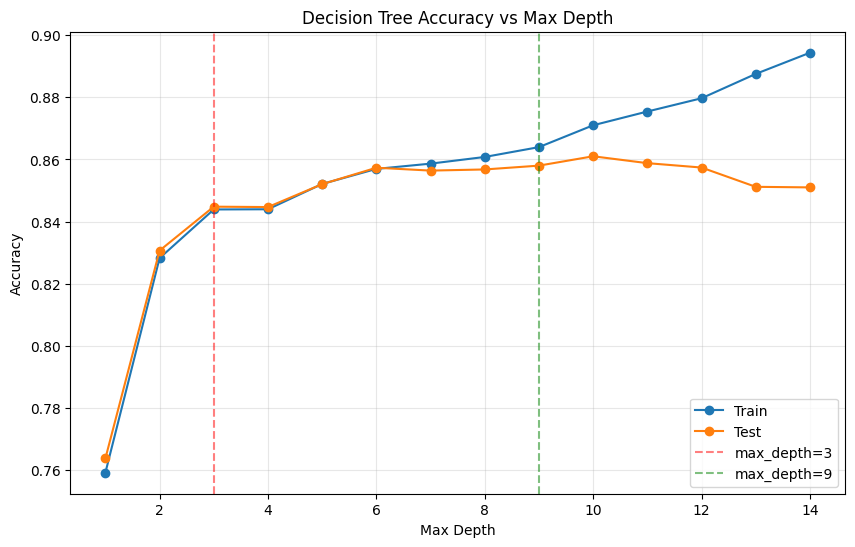

In [20]:
# Test different max_depth values
depths = range(1, 15)
train_accuracies = []
test_accuracies = []

for depth in depths:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=17)
    tree.fit(X_train, y_train)
    
    train_acc = accuracy_score(y_train, tree.predict(X_train))
    test_acc = accuracy_score(y_test, tree.predict(X_test))
    
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)

# Plot results
plt.figure(figsize=(10, 6))
plt.plot(depths, train_accuracies, marker='o', label='Train')
plt.plot(depths, test_accuracies, marker='o', label='Test')
plt.axvline(3, color='red', linestyle='--', alpha=0.5, label='max_depth=3')
plt.axvline(9, color='green', linestyle='--', alpha=0.5, label='max_depth=9')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy vs Max Depth')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
# Show accuracy table
results_df = pd.DataFrame({
    'max_depth': depths,
    'train_accuracy': train_accuracies,
    'test_accuracy': test_accuracies
})

print("Accuracy by max_depth:")
print(results_df)

Accuracy by max_depth:
    max_depth  train_accuracy  test_accuracy
0           1        0.759190       0.763774
1           2        0.828230       0.830662
2           3        0.843893       0.844788
3           4        0.843954       0.844666
4           5        0.852093       0.852036
5           6        0.856945       0.857318
6           7        0.858635       0.856397
7           8        0.860784       0.856766
8           9        0.863948       0.857994
9          10        0.870981       0.861004
10         11        0.875403       0.858792
11         12        0.879672       0.857380
12         13        0.887503       0.851176
13         14        0.894321       0.850992
